# FaceInsight-AI EDA

# Overview
This notebook performs Exploratory Data Analysis (EDA) on the CelebA dataset using KaggleHub. It examines three CSV files extracted from the dataset:
- `list_attr_celeba.csv` — facial attribute annotations
- `list_bbox_celeba.csv` — bounding box coordinates for face regions
- `list_eval_partition.csv` — train/validation/test split indicators

The notebook covers data loading, summary statistics, and visualization of distributions, correlations, and scatter relationships across each dataset.

# Setup
Import required libraries and set up the environment for analysis.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

# Utility Functions
Helper functions for visualizing data distributions, correlation matrices, and scatter plots.

In [3]:
def plotPerColumnDistribution(df, nGraphPerRow, nGraphShown):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]]
    if df.shape[1] == 0:
        print('No valid columns to plot')
        return
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = int(np.ceil(nCol / nGraphPerRow))
    plt.figure(figsize=(nGraphPerRow * 6, nGraphRow * 4))
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        col = columnNames[i]
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col].hist(bins=30)
        else:
            df[col].value_counts().plot(kind='bar')
        plt.title(f'{col} Distribution')
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()

def plotCorrelationMatrix(df, size):
    corr = df.select_dtypes(include=[np.number]).corr()
    if corr.shape[0] < 2:
        print('Not enough numeric columns for correlation matrix')
        return
    plt.figure(figsize=(size, size))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()

def plotScatterMatrix(df, plotSize, textSize):
    numeric = df.select_dtypes(include=[np.number])
    if numeric.shape[1] < 2:
        print('Not enough numeric columns for scatter matrix')
        return
    if numeric.shape[1] > 10:
        numeric = numeric.iloc[:, :10]
    plt.figure(figsize=(plotSize, plotSize))
    pd.plotting.scatter_matrix(numeric, figsize=(plotSize, plotSize))
    plt.show()

# Data Download
Download the CelebA dataset from Kaggle using `kagglehub`. The dataset is persisted locally and can be reused across notebook sessions.

# DataFrame 1 — Facial Attributes (`list_attr_celeba.csv`)
This dataset contains 40 binary facial attributes (e.g., Smiling, Male, Wearing_Hat) annotated for each celebrity image. We load a sample of 1000 rows and visualize the distributions and correlations.

In [ ]:
# Read the full attribute file (CelebA has 202,599 rows).
# The original nRowsRead=1000 threw away >99% of the data, which is the
# single biggest reason the model below underperforms.
df1 = pd.read_csv(os.path.join(DATA_DIR, 'list_attr_celeba.csv'), delimiter=',')
df1.dataframeName = 'list_attr_celeba.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')


In [6]:
df1.head(5)

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


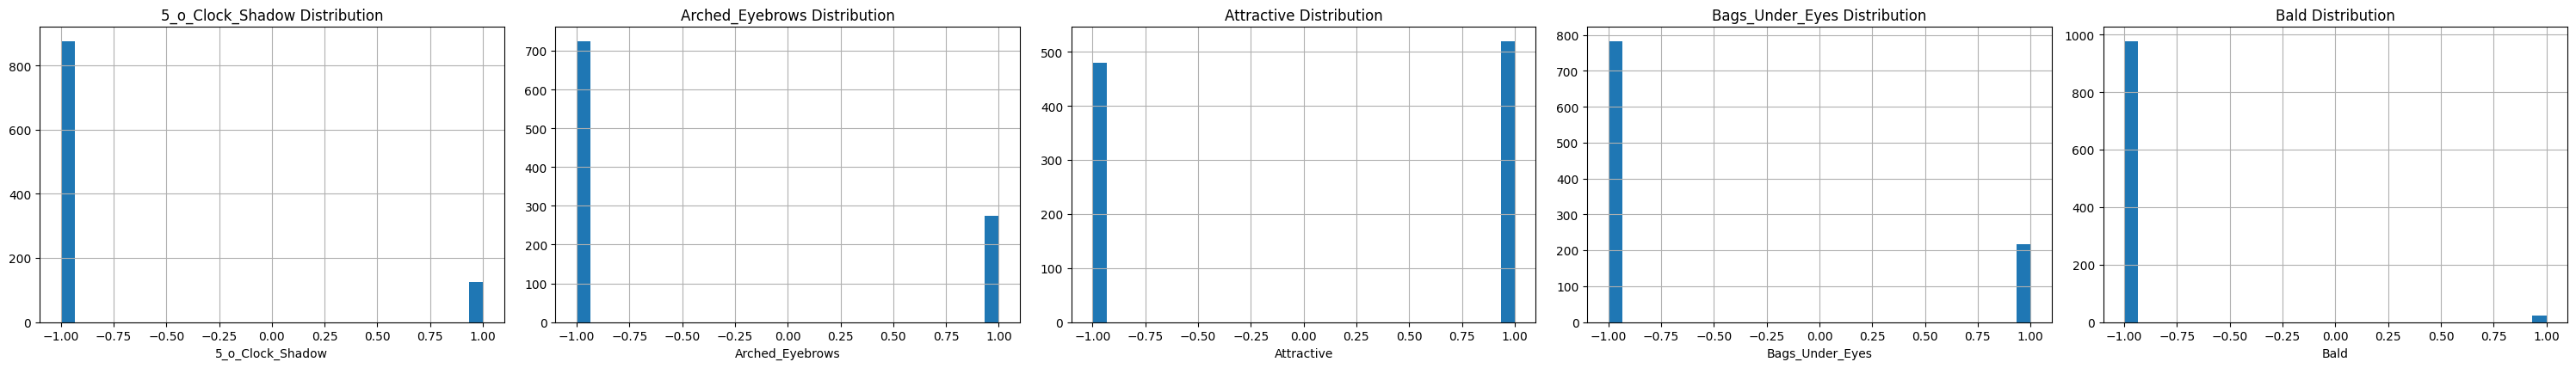

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plotPerColumnDistribution(df, nGraphPerRow, nGraphShown):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]]
    if df.shape[1] == 0:
        print('No valid columns to plot')
        return
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = int(np.ceil(nCol / nGraphPerRow))
    plt.figure(figsize=(nGraphPerRow * 6, nGraphRow * 4))
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        col = columnNames[i]
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col].hist(bins=30)
        else:
            df[col].value_counts().plot(kind='bar')
        plt.title(f'{col} Distribution')
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()

plotPerColumnDistribution(df1, 10, 5)

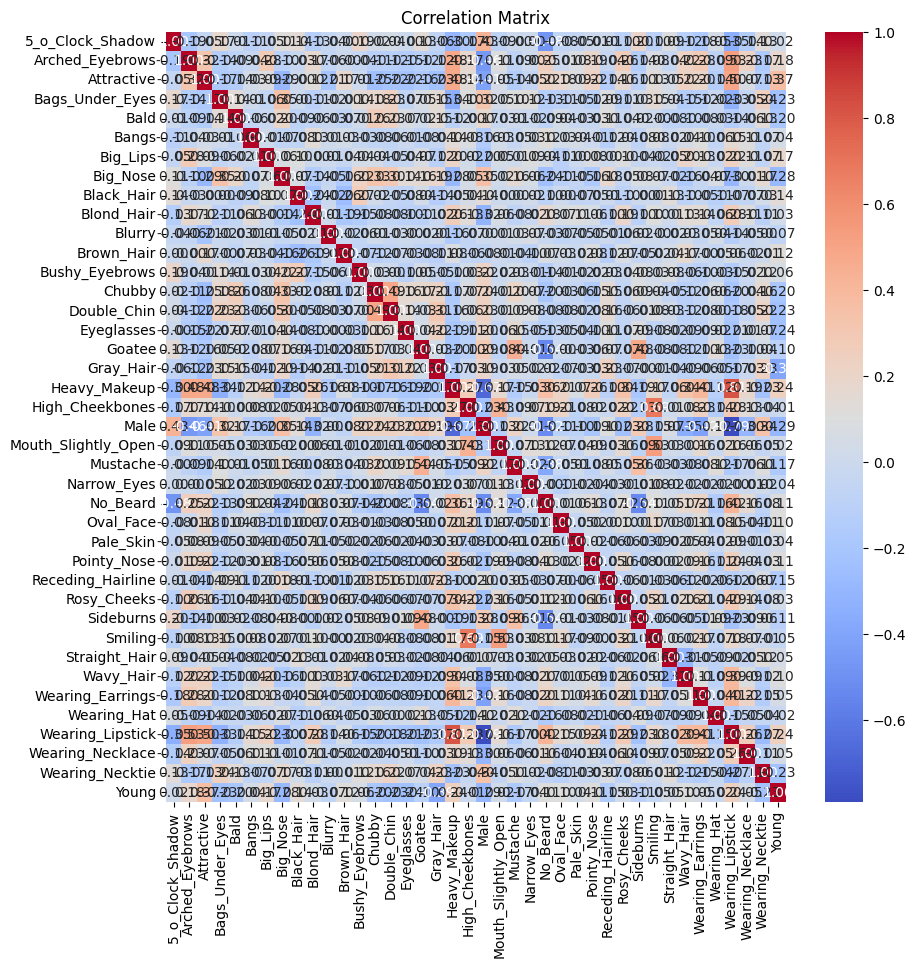

In [8]:
def plotCorrelationMatrix(df, size):
    corr = df.select_dtypes(include=[np.number]).corr()
    if corr.shape[0] < 2:
        print('Not enough numeric columns for correlation matrix')
        return
    plt.figure(figsize=(size, size))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()

plotCorrelationMatrix(df1, 10)

<Figure size 2000x2000 with 0 Axes>

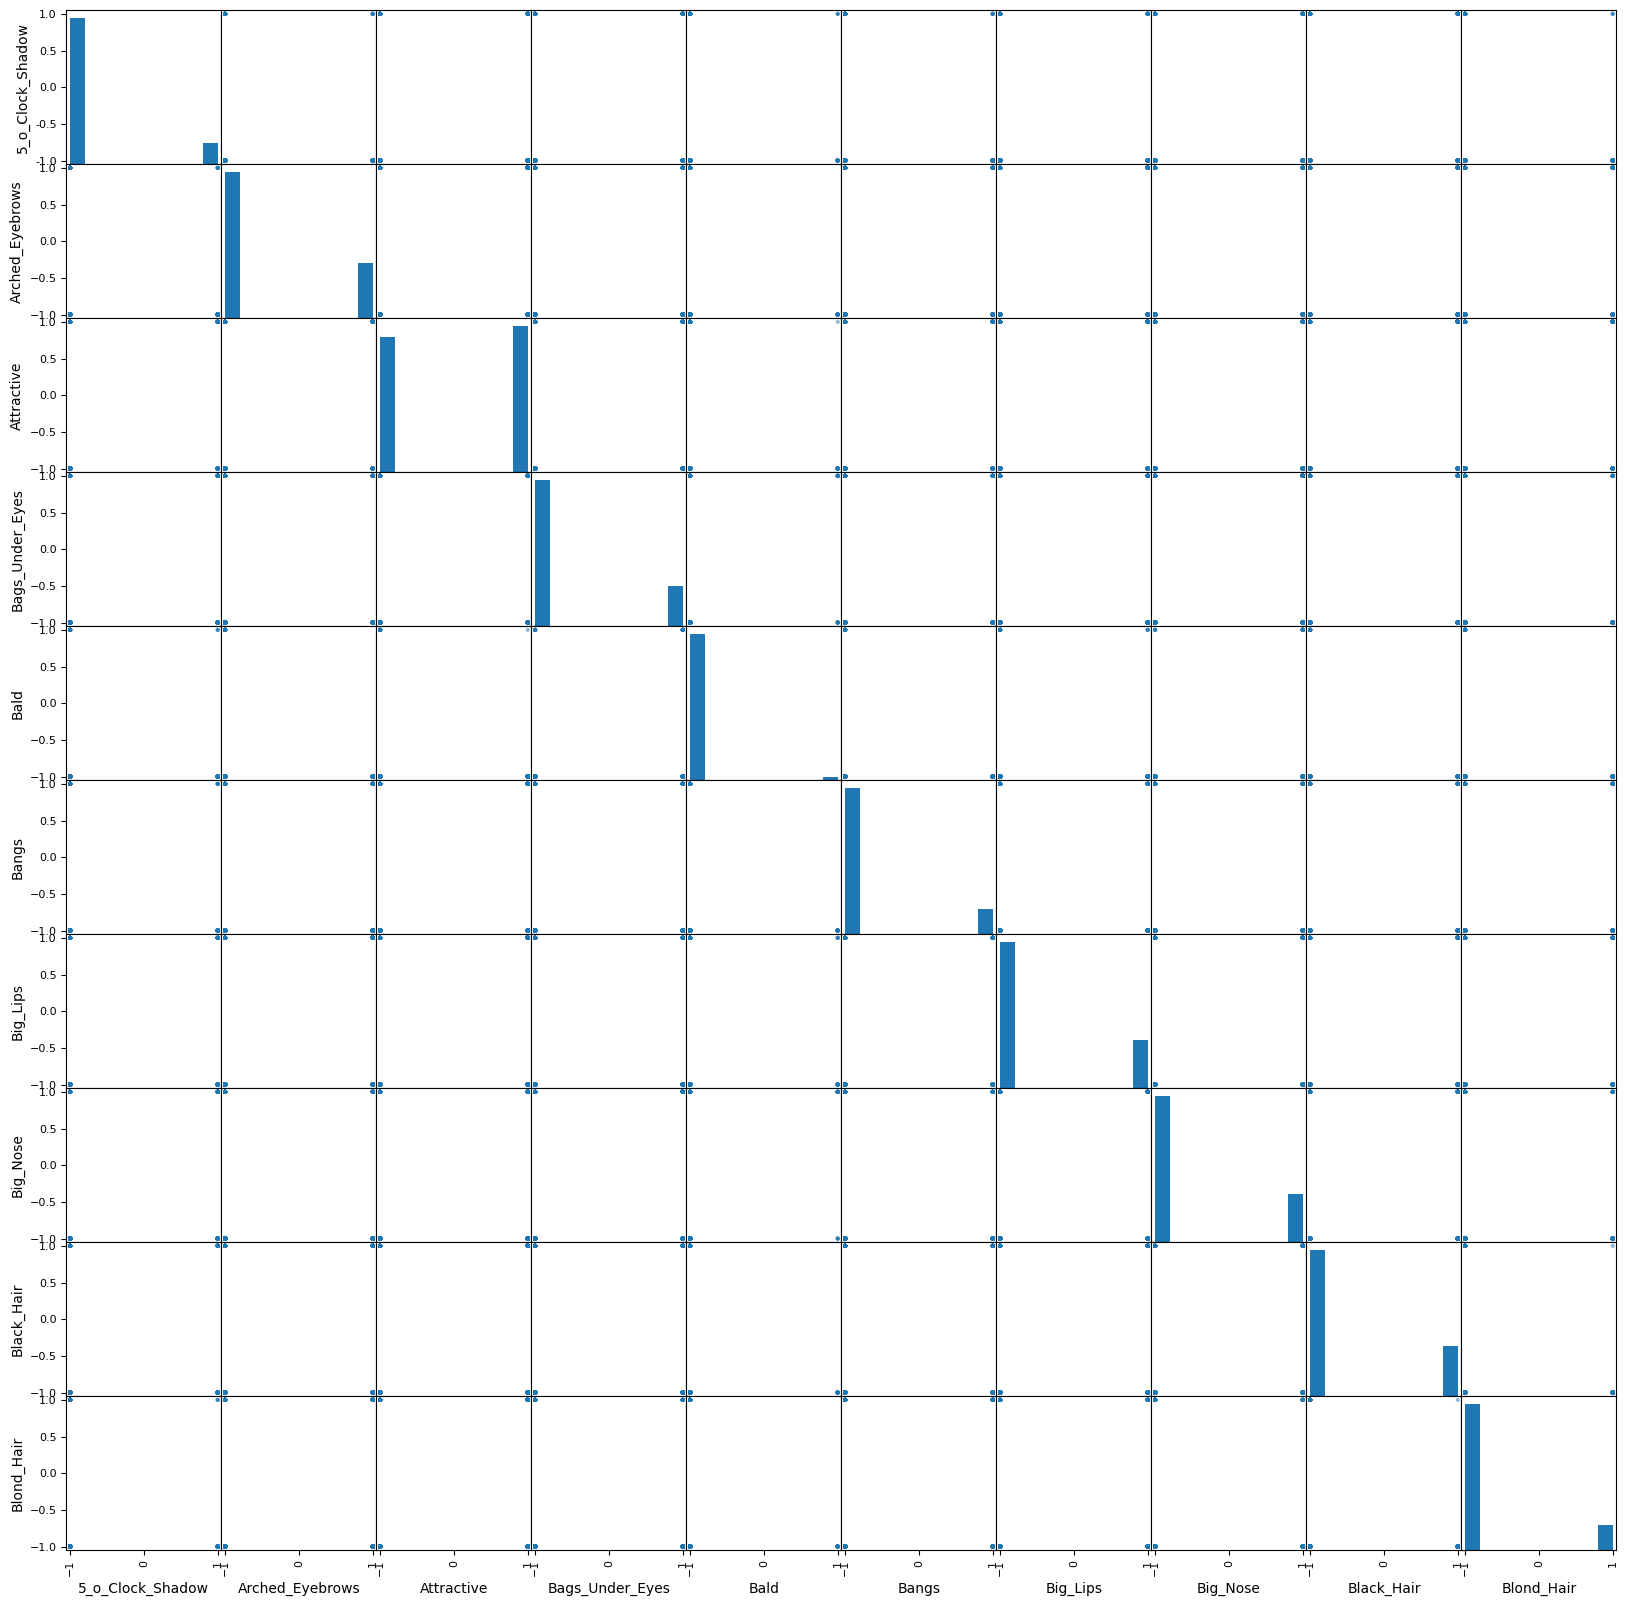

In [9]:
plotScatterMatrix(df1, 20, 10)

# DataFrame 2 — Bounding Boxes (`list_bbox_celeba.csv`)
This dataset contains bounding box coordinates (`x`, `y`, `width`, `height`) for face regions in each image, along with `confidence` and `target`. We visualize the distributions and correlations.

In [10]:
nRowsRead = 1000
df2 = pd.read_csv(os.path.join(DATA_DIR, 'list_bbox_celeba.csv'), delimiter=',', nrows=nRowsRead)
df2.dataframeName = 'list_bbox_celeba.csv'
nRow, nCol = df2.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1000 rows and 5 columns


In [11]:
df2.head(5)

,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166


In [12]:
plotPerColumnDistribution(df2, 10, 5)

No valid columns to plot


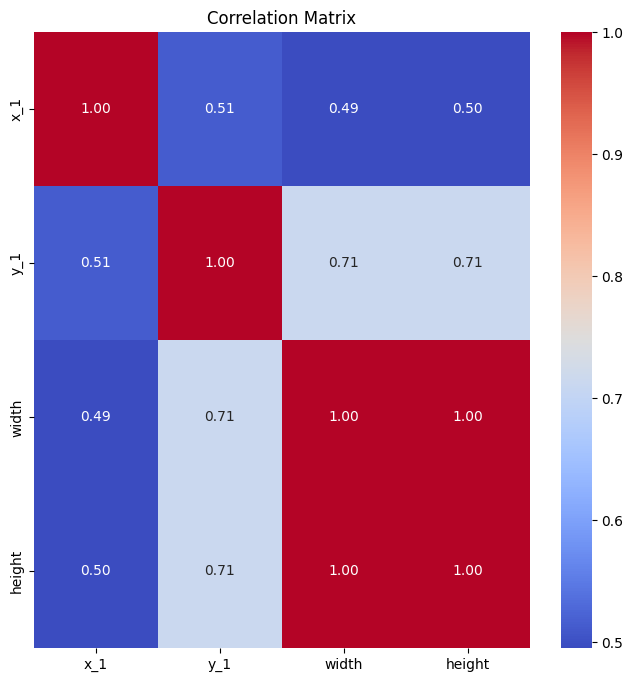

In [13]:
plotCorrelationMatrix(df2, 8)

<Figure size 1200x1200 with 0 Axes>

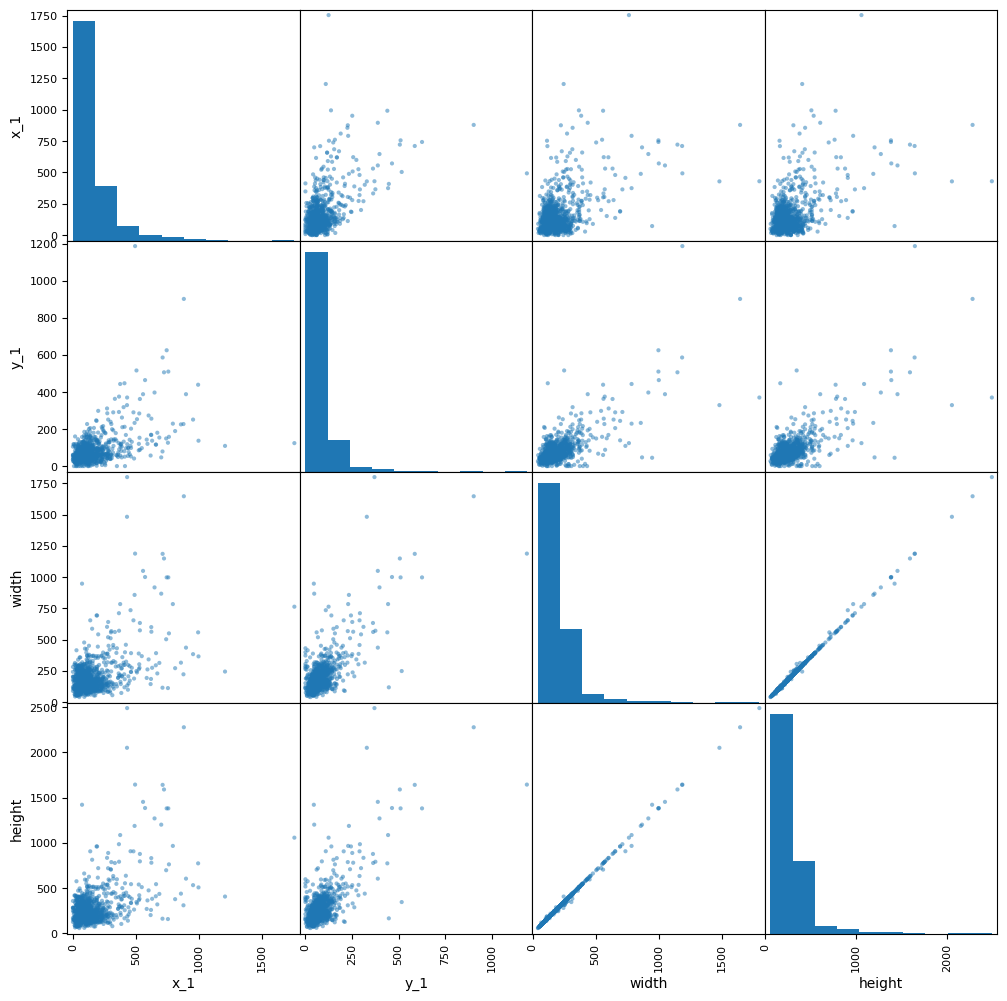

In [14]:
plotScatterMatrix(df2, 12, 10)

# DataFrame 3 — Evaluation Partition (`list_eval_partition.csv`)
This dataset assigns each image to a partition (`0` = Training, `1` = Validation, `2` = Test), enabling reproducibility of train/val/test splits.

In [15]:
nRowsRead = 1000
df3 = pd.read_csv(os.path.join(DATA_DIR, 'list_eval_partition.csv'), delimiter=',', nrows=nRowsRead)
df3.dataframeName = 'list_eval_partition.csv'
nRow, nCol = df3.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1000 rows and 2 columns


In [16]:
df3.head(5)

,image_id,partition
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,0
3,000004.jpg,0
4,000005.jpg,0


In [18]:
plotPerColumnDistribution(df3, 10, 5)

No valid columns to plot


In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
from sklearn.model_selection import train_test_split

# Drop image_id, it's an identifier, not a feature
features_df = df1.drop('image_id', axis=1)

# 'Young' is a binary attribute encoded as -1 / 1 in CelebA.
# Treating it as a continuous target (MSE / linear output) was the core bug:
# it's a classification problem, not a regression problem.
y = (features_df['Young'] == 1).astype(int)
X = features_df.drop('Young', axis=1)

# stratify=y keeps the same class balance in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True))


In [ ]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')  # sigmoid for binary classification
])

model.summary()


In [ ]:
# (duplicate model definition removed)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5
)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

loss, accuracy, auc = model.evaluate(X_test, y_test)
print(f"Test loss:     {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")
print(f"Test AUC:      {auc:.4f}")

pred_proba = model.predict(X_test).flatten()
pred_labels = (pred_proba > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, pred_labels))

print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_labels))

print("ROC-AUC:", roc_auc_score(y_test, pred_proba))


In [ ]:
# Predicted probabilities that a face is 'Young'
predictions = model.predict(X_test)


In [ ]:
model.save("young_attribute_classifier.keras")


In [ ]:
loaded = tf.keras.models.load_model("young_attribute_classifier.keras")

pred = loaded.predict(X_test[:5])
print(pred)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()
